# Incidence angle

I'd like to verify that my incidence angles are being calculated correctly with `uavsar_pytools` by comparing two flight paths and comparing to the JPL .inc product. 

In [1]:
# import libraries
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxa
import py3dep
from shapely.geometry import box
from rasterio.enums import Resampling

from pathlib import Path
from datetime import datetime
import tifffile as tif

import matplotlib.pyplot as plt

# uavsar code
from uavsar_pytools.convert.tiff_conversion import read_annotation
from uavsar_pytools.incidence_angle import calc_inc_angle

/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = '/bsuscratch/julialober/coherence_data/'

inc_fp = f'{data_dir}/jpl_products/lowman_05208_21021_007_210322_L090_CX_01.inc'
lkv_fp = f'{data_dir}/uavsar_geoslcs/lowman/05208/lowman_05208_01_BU_s1_2x8.lkv' #.x.tif, .y.tif, .z.tif

In [3]:
rows = 16418
columns = 26700
arr = np.fromfile(inc_fp, dtype='<f4')  # little-endian float32
arr = arr.reshape((rows, columns))


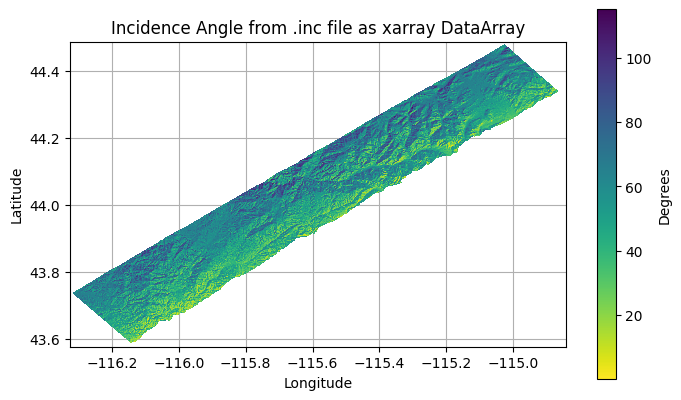

In [4]:
ul_pixel_lat = 44.48811432  # Center Latitude of Upper Left Pixel of INC Image
ul_pixel_lon = -116.32530528000001  # Center Longitude of Upper Left
pixel_lat = -5.556e-05  # INC Latitude Pixel Spacing
pixel_lon = 5.556e-05  # INC Longitude Pixel Spacing

# given these parameters, georeference the incidence angle array 
lr_pixel_lat = ul_pixel_lat + (arr.shape[0] * pixel_lat)  # calculate lower right pixel latitude
lr_pixel_lon = ul_pixel_lon + (arr.shape[1] * pixel_lon)  # calculate lower right pixel longitude


x = np.linspace(ul_pixel_lon + pixel_lon/2, lr_pixel_lon - pixel_lon/2, columns)
y = np.linspace(ul_pixel_lat + pixel_lat/2, lr_pixel_lat - pixel_lat/2, rows)

inc_jpl = xr.DataArray(
    arr,
    coords={"y": y, "x": x},
    dims=("y", "x"),
)

inc_jpl.values = np.rad2deg(inc_jpl.values)
inc_jpl.values = np.where((0 <= inc_jpl.values) & (inc_jpl.values < 180), inc_jpl.values, np.nan)


# downsample and plot data array using rioxarray
fig, ax = plt.subplots(figsize=(8, 6))
da_ds = inc_jpl.isel(x=slice(None, None, 5), y=slice(None, None, 5))
# da_ds = np.rad2deg(da_ds)  # convert from radians to degrees
da_plot = da_ds.plot(ax=ax, cmap='viridis_r', add_colorbar=False)
ax.set_title('Incidence Angle from .inc file as xarray DataArray')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.colorbar(da_plot, ax=ax, orientation='vertical', label='Degrees', shrink=0.8)
plt.show()

inc_jpl = inc_jpl.rio.write_crs('EPSG:4326')

### Open the look vector files and get DEM 

In [35]:
# --- 2. Load Look Vectors (in EPSG:4326) ---
print("Loading LKV files...")
lkv_x_4326 = rxa.open_rasterio(lkv_fp + '.x.tif', masked=True).squeeze()
lkv_y_4326 = rxa.open_rasterio(lkv_fp + '.y.tif', masked=True).squeeze()
lkv_z_4326 = rxa.open_rasterio(lkv_fp + '.z.tif', masked=True).squeeze()

# --- 3. Fetch the DEM using py3dep ---
# Extract bounding box from the LKV file to ensure perfect overlap
aoi_4326 = box(*lkv_x_4326.rio.bounds())
print("Fetching DEM via py3dep...")
dem_4326 = py3dep.get_dem(geometry=aoi_4326, resolution=10, crs="EPSG:4326") 
# 9.7 s for 15 m resolution
# timed out for 5 m resolution 
# 45 s for 10 m resolution 

Loading LKV files...
Fetching DEM via py3dep...


### Calculate incidence angle

In [36]:
# --- 4. Reproject to UTM Zone 11N (Meters) ---
utm_crs = "EPSG:32611" # Lowman, ID is in UTM Zone 11N
res_m = 5.556 # Standard UAVSAR pixel resolution in meters

print(f"Reprojecting arrays to {utm_crs}...")
lkv_x_utm = lkv_x_4326.rio.reproject(utm_crs, resolution=res_m)
lkv_y_utm = lkv_y_4326.rio.reproject(utm_crs, resolution=res_m)
lkv_z_utm = lkv_z_4326.rio.reproject(utm_crs, resolution=res_m)

# Use reproject_match to force the DEM to perfectly align with the new LKV grid
dem_utm = dem_4326.rio.reproject_match(lkv_x_utm)

# --- 5. Calculate True Incidence Angle ---
# We pass the raw numpy arrays (.values) directly into our fixed function!
print("Calculating incidence angle...")
inc_utm_arr = calc_inc_angle(
    dem=dem_utm.values,
    lkv_x=lkv_x_utm.values,
    lkv_y=lkv_y_utm.values,
    lkv_z=lkv_z_utm.values,
    pixel_size=res_m
)

# --- 6. Reproject Back to EPSG:4326 ---
print("Reprojecting results back to EPSG:4326...")
# First, wrap the numpy array back into an xarray object with the UTM spatial info
inc_utm_da = lkv_x_utm.copy(data=inc_utm_arr)

# Then, warp it back to 4326 so it perfectly matches the original grid
inc_4326_da = inc_utm_da.rio.reproject_match(lkv_x_4326)

Reprojecting arrays to EPSG:32611...
Calculating incidence angle...
Reprojecting results back to EPSG:4326...


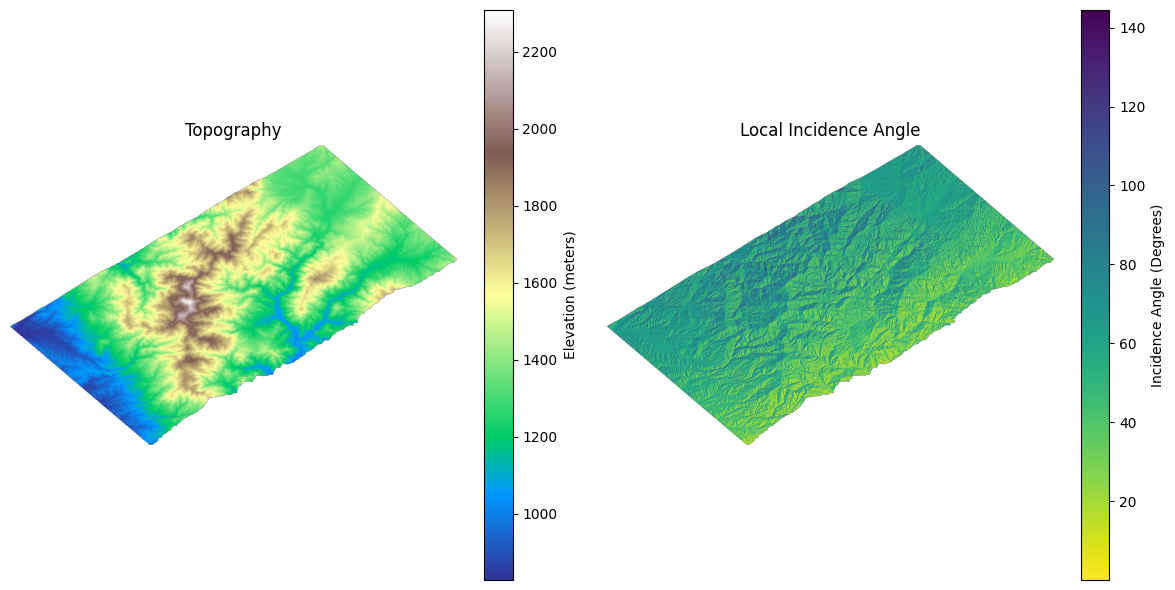

In [37]:
# Set a downsampling factor to speed up plotting (e.g., 10 means take every 10th pixel)
factor = 10

# 1. Trim and mask the DEM to perfectly match the incidence angle swath
# reproject_match perfectly aligns the grids, and .where applies the NaN mask from the radar data
dem_matched = dem_4326.rio.reproject_match(inc_4326_da)
dem_trimmed = dem_matched.where(inc_4326_da.notnull())

# 2. Downsample the arrays for lightning-fast plotting using NumPy slicing
dem_plot_data = dem_trimmed.squeeze().values[::factor, ::factor]
inc_plot_data = inc_4326_da.squeeze().values[::factor, ::factor]

# 3. Generate the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: The DEM (Elevation)
dem_plot = ax1.imshow(dem_plot_data, cmap='terrain')
ax1.set_title(f"Topography")
fig.colorbar(dem_plot, ax=ax1, label='Elevation (meters)')
ax1.axis('off') # Hides axis ticks for a cleaner map look

# Plot 2: The Calculated Incidence Angle
inc_plot = ax2.imshow(inc_4326_da.values, cmap='viridis_r')
ax2.set_title(f"Local Incidence Angle")
fig.colorbar(inc_plot, ax=ax2, label='Incidence Angle (Degrees)')
ax2.axis('off')

plt.tight_layout()
plt.show()

In [38]:
dem_utm.rio.transform()

Affine(5.555999999999996, 0.0, 555297.2984174002,
       0.0, -5.556000000000044, 4869091.394295361)

### Match the jpl incidence angle with the calculated incidence angle

In [39]:
jpl_matched = inc_jpl.rio.reproject_match(inc_4326_da)
jpl_matched = jpl_matched.where(inc_4326_da.notnull())

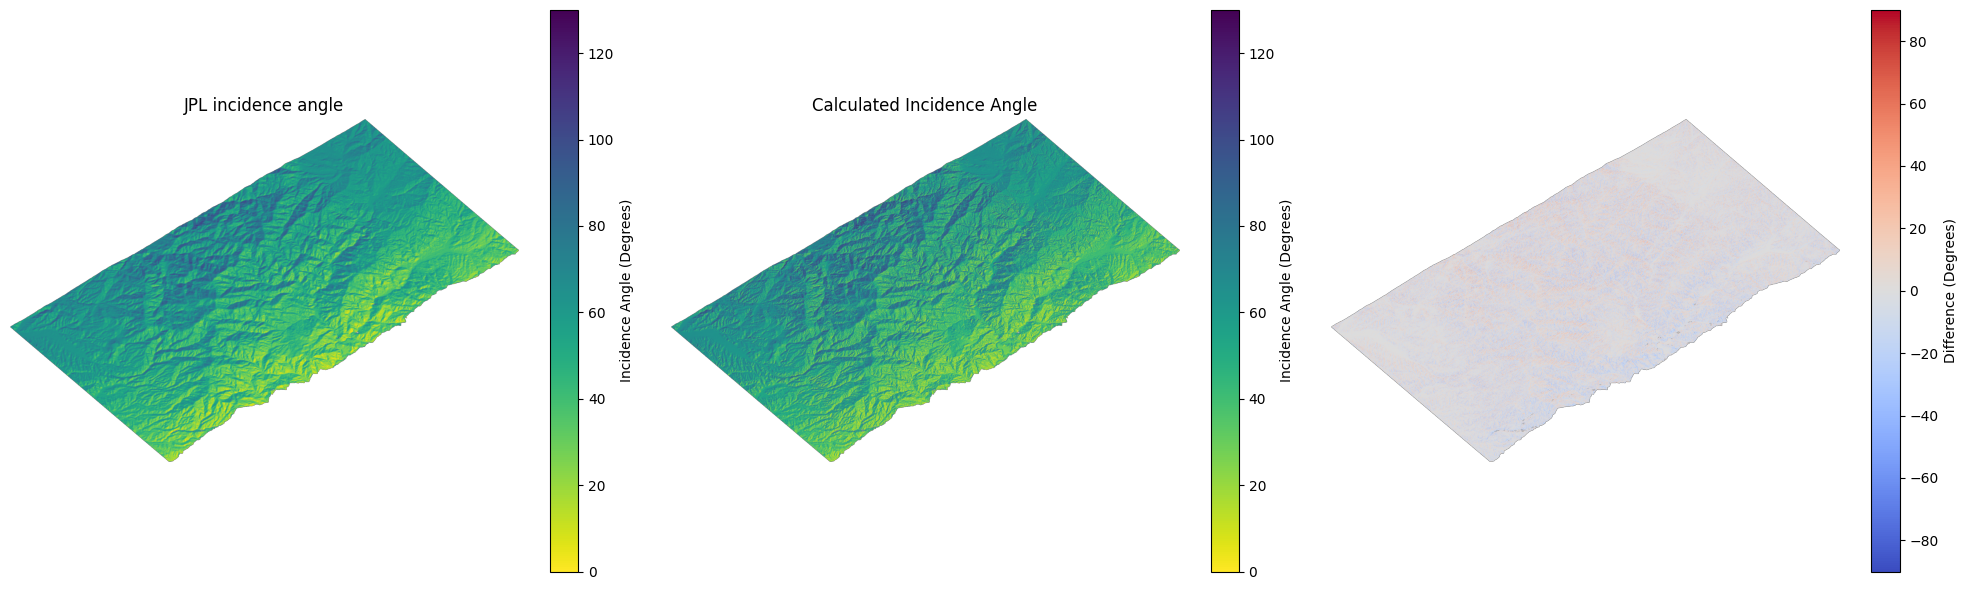

In [40]:
# Set a downsampling factor to speed up plotting (e.g., 10 means take every 10th pixel)
factor = 5

# 2. Downsample the arrays for lightning-fast plotting using NumPy slicing
jpl_plot_data = jpl_matched.squeeze().values[::factor, ::factor]
inc_plot_data = inc_4326_da.squeeze().values[::factor, ::factor]

# 3. Generate the plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: The DEM (Elevation)
jpl_plot = ax1.imshow(jpl_plot_data, vmin=0, vmax=130, cmap='viridis_r')
ax1.set_title(f"JPL incidence angle")
fig.colorbar(jpl_plot, ax=ax1, label='Incidence Angle (Degrees)')
ax1.axis('off') # Hides axis ticks for a cleaner map look

# Plot 2: The Calculated Incidence Angle
inc_plot = ax2.imshow(inc_plot_data, vmin=0, vmax=130, cmap='viridis_r')
ax2.set_title(f"Calculated Incidence Angle")
fig.colorbar(inc_plot, ax=ax2, label='Incidence Angle (Degrees)')
ax2.axis('off')

# Assuming you have both loaded as xarray DataArrays or numpy arrays
diff_map = jpl_plot_data - inc_plot_data

diff_plot = ax3.imshow(diff_map, cmap='coolwarm', vmin=-90, vmax=90)
fig.colorbar(diff_plot, ax=ax3, label='Difference (Degrees)')
ax3.axis('off')

plt.tight_layout()
plt.show()

r-squared = 0.407


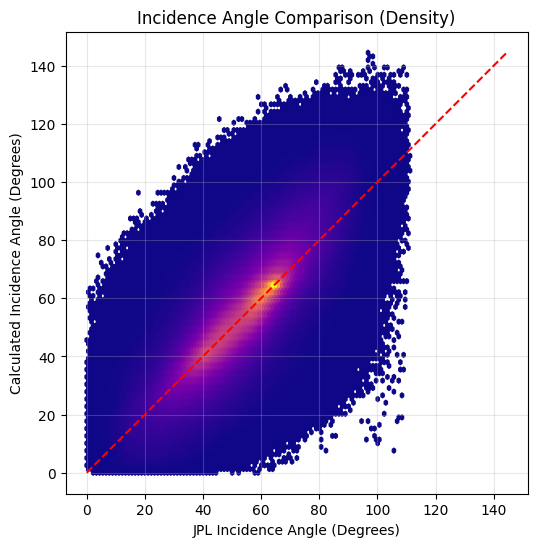

In [41]:
# 1. Flatten your arrays to 1D
jpl_flat = jpl_matched.values.flatten()
calc_flat = inc_4326_da.values.flatten() # Or whatever your calculated variable is named

# 2. Mask out the NaNs (Crucial! hist2d will break or look weird with NaNs)
valid_mask = ~np.isnan(jpl_flat) & ~np.isnan(calc_flat)
x = jpl_flat[valid_mask]
y = calc_flat[valid_mask]

# 3. Generate the Density Heatmap
fig, ax = plt.subplots(figsize=(6, 6))

# bins=100 divides the data into a 100x100 grid. 
# cmin=1 ensures that bins with 0 points remain transparent/white instead of colored
h = ax.hexbin(x, y, bins=200, cmap='plasma', mincnt=1)
ax.set_aspect('equal')

# Add a colorbar to show what the colors represent
# plt.colorbar(h[3], label='Number of Pixels')

# 4. Add a 1:1 reference line
# Since you are comparing to a "gold standard", this line shows where a perfect match would be
min_val = min(np.nanmin(x), np.nanmin(y))
max_val = max(np.nanmax(x), np.nanmax(y))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5)

# Formatting
ax.set_xlabel('JPL Incidence Angle (Degrees)')
ax.set_ylabel('Calculated Incidence Angle (Degrees)')

# Source - https://stackoverflow.com/a/64902907
# Posted by John Jack Lewis
# Retrieved 2026-03-28, License - CC BY-SA 4.0
from sklearn.metrics import r2_score
print("r-squared = {:.3f}".format(r2_score(x, y)))

plt.title('Incidence Angle Comparison (Density)')
plt.grid(alpha=0.3)

plt.show()

# OLD STUFF 

In [6]:
# write the incidence angle array to a tif files using rasterio
import rasterio

out_dir = '../data/snowex_lowman/slcs_geocoded/'
out_fp = "lowman_05208_inc.tif"
height, width = inc_spatial.shape
transform = reprojected_dem.rio.transform()
crs = reprojected_dem.rio.crs

with rasterio.open(
    out_dir + out_fp,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype='float32',
    crs=crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(inc_spatial.astype('float32'), 1)

In [7]:
# file.inc consists of 4-byte floating point values in little endian order

fp = '../data/snowex_lowman/jpl_interferograms/lowman_05208_21021_007_210322_L090_CX_01.inc'
rows = 16418
columns = 26700
arr = np.fromfile(fp, dtype='<f4')  # little-endian float32
arr = arr.reshape((rows, columns))


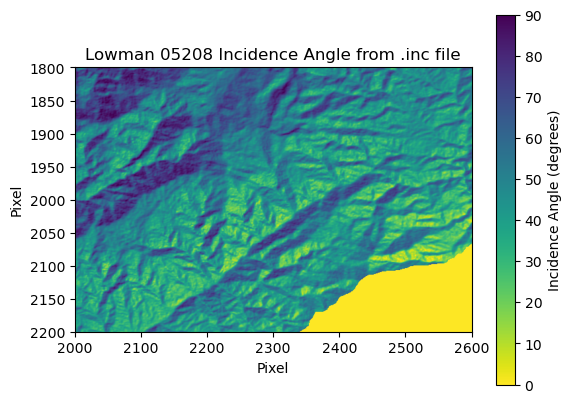

In [8]:
# downsample and plot
arr_ds = arr[::5, ::5]
arr_ds = np.rad2deg(arr_ds)  # convert from radians to degrees
plt.imshow(arr_ds, cmap='viridis_r', vmin=0, vmax=90)
# plt.invert_yaxis()
plt.xlim(2000, 2600)
plt.ylim(2200, 1800)
plt.colorbar(label='Incidence Angle (degrees)')
plt.title('Lowman 05208 Incidence Angle from .inc file')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
plt.show()

inc.row_addr                                      (deg)       = 44.48811432            ; Center Latitude of Upper Left Pixel of INC Image 
inc.col_addr                                      (deg)       = -116.32530528000001    ; Center Longitude of Upper Left Pixel of INC Image
inc.row_mult                                      (deg/pixel) = -5.556e-05             ; INC Latitude Pixel Spacing
inc.col_mult                                      (deg/pixel) = 5.556e-05              ; INC Longitude Pixel Spacing

(-115.7352319093607, 43.90718161502215, -115.63548033331044, 43.98397534443853)


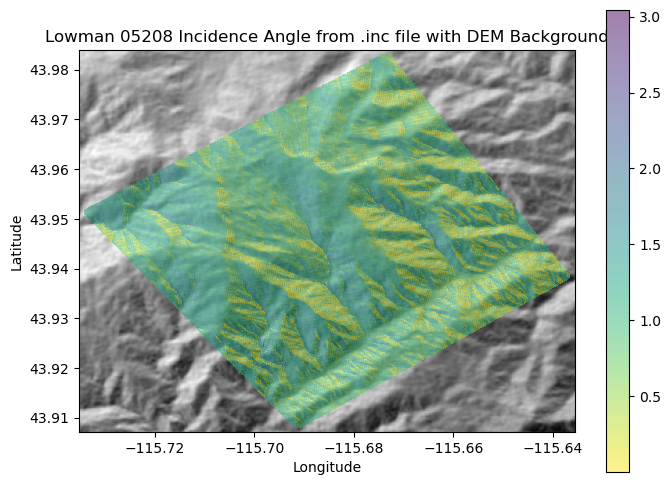

In [9]:
ul_pixel_lat = 44.48811432  # Center Latitude of Upper Left Pixel of INC Image
ul_pixel_lon = -116.32530528000001  # Center Longitude of Upper Left
pixel_lat = -5.556e-05  # INC Latitude Pixel Spacing
pixel_lon = 5.556e-05  # INC Longitude Pixel Spacing

# given these parameters, georeference the incidence angle array 
lr_pixel_lat = ul_pixel_lat + (arr.shape[0] * pixel_lat)  # calculate lower right pixel latitude
lr_pixel_lon = ul_pixel_lon + (arr.shape[1] * pixel_lon)  # calculate lower right pixel longitude

bounds = inc_spatial.rio.bounds()
print(bounds)

# plot only a red outline using the upper left and lower right coordinates and put the dem in the background
fig, ax = plt.subplots(figsize=(8, 6))
extent = [ul_pixel_lon, lr_pixel_lon, lr_pixel_lat, ul_pixel_lat]

# plot a red outline around the extent of the incidence angle array
dem_plt = inc_spatial.plot(ax=ax, cmap='viridis_r', alpha=0.5)
ax.add_patch(plt.Rectangle((ul_pixel_lon, lr_pixel_lat), lr_pixel_lon - ul_pixel_lon, ul_pixel_lat - lr_pixel_lat, linewidth=2, edgecolor='red', facecolor='none'))
ax.imshow(arr_ds, cmap='gray', extent=extent, vmin=0, vmax=90) 
# plt.xlim(ul_pixel_lon, lr_pixel_lon)
# plt.ylim(lr_pixel_lat, ul_pixel_lat)
plt.xlim(bounds[0], bounds[2])
plt.ylim(bounds[1], bounds[3])
plt.title('Lowman 05208 Incidence Angle from .inc file with DEM Background')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Based on the figure above, I think the incidence angle calculation I am doing is not working. I have had issues with rasters printing out at a 90deg rotation, so I suspect that one of my inputs has this problem, since it visually looks to be rotated 90 deg. 

Below, I am using the downloaded incidence angle file from JPL, which is included in the PolSAR product. I might just do this for the future, since they are available and it doesn't seem worth my time to reinvent the wheel! 

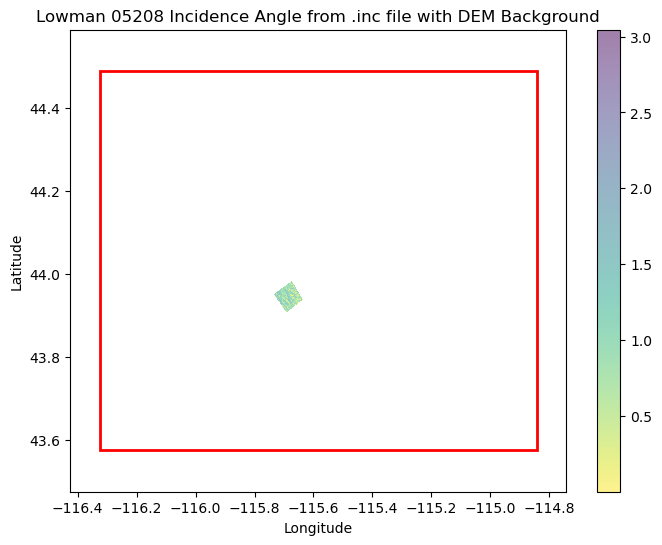

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
extent = [ul_pixel_lon, lr_pixel_lon, lr_pixel_lat, ul_pixel_lat]

# plot a red outline around the extent of the incidence angle array
dem_plt = inc_spatial.plot(ax=ax, cmap='viridis_r', alpha=0.5)
ax.add_patch(plt.Rectangle((ul_pixel_lon, lr_pixel_lat), lr_pixel_lon - ul_pixel_lon, ul_pixel_lat - lr_pixel_lat, linewidth=2, edgecolor='red', facecolor='none'))
# ax.imshow(arr_ds, cmap='gray', extent=extent, vmin=0, vmax=90) 
plt.xlim(ul_pixel_lon - 0.1, lr_pixel_lon + 0.1)
plt.ylim(lr_pixel_lat - 0.1, ul_pixel_lat + 0.1)
# plt.xlim(bounds[0], bounds[2])
# plt.ylim(bounds[1], bounds[3])
plt.title('Lowman 05208 Incidence Angle from .inc file with DEM Background')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Compare with the downloaded JPL product. 

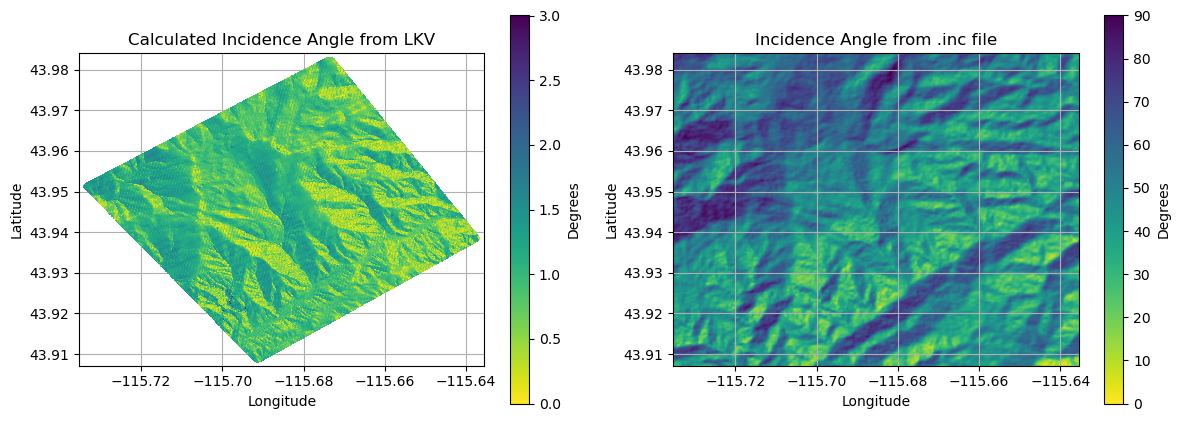

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes = axes.flatten()
# plot inc_spatial and arr_ds side by side
inc_plot = inc_spatial.plot(ax=axes[0], cmap='viridis_r', vmin=0, vmax=3, add_colorbar=False)
axes[0].set_title('Calculated Incidence Angle from LKV')
axes[0].set_aspect('equal')
axes[0].grid(True)
axes[0].set_axisbelow(True)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_xlim(bounds[0], bounds[2])
axes[0].set_ylim(bounds[1], bounds[3])
fig.colorbar(inc_plot, ax=axes[0], orientation='vertical', label='Degrees', shrink=0.4)
arr_plot = axes[1].imshow(arr_ds, cmap='viridis_r', vmin=0, vmax=90, extent=extent)
axes[1].set_title('Incidence Angle from .inc file')
axes[1].set_aspect('equal')
axes[1].grid(True)
axes[1].set_axisbelow(True)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_xlim(bounds[0], bounds[2])
axes[1].set_ylim(bounds[1], bounds[3])
fig.colorbar(arr_plot, ax=axes[1], orientation='vertical', label='Degrees', shrink=0.4)
plt.tight_layout()
plt.show()

[-116.3252775  -116.32522194 -116.32516638 ... -114.84199218 -114.84193662
 -114.84188106]
[44.48808654 44.48803098 44.48797542 ... 43.57606914 43.57601358
 43.57595802]


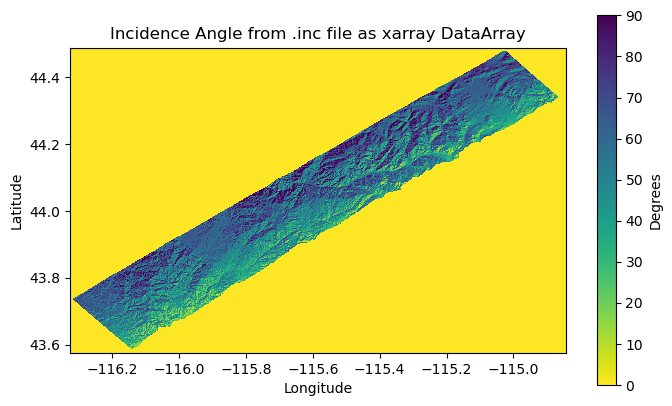

In [ ]:
x = np.linspace(ul_pixel_lon + pixel_lon/2, lr_pixel_lon - pixel_lon/2, columns)
y = np.linspace(ul_pixel_lat + pixel_lat/2, lr_pixel_lat - pixel_lat/2, rows)
print(x)
print(y)

da = xr.DataArray(
    arr,
    coords={"y": y, "x": x},
    dims=("y", "x"),
)

# downsample and plot data array using rioxarray
fig, ax = plt.subplots(figsize=(8, 6))
da_ds = da.isel(x=slice(None, None, 5), y=slice(None, None, 5))
da_ds = np.rad2deg(da_ds)  # convert from radians to degrees
da_plot = da_ds.plot(ax=ax, cmap='viridis_r', vmin=0, vmax=90, add_colorbar=False)
ax.set_title('Incidence Angle from .inc file as xarray DataArray')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.colorbar(da_plot, ax=ax, orientation='vertical', label='Degrees', shrink=0.8)
plt.show()

da = da.rio.write_crs(inc_spatial.rio.crs)
# da = da.rio.write_transform(rxa.transform.from_bounds(ul_pixel_lon, lr_pixel_lat, lr_pixel_lon, ul_pixel_lat, columns, rows))
da_resamp = da.rio.reproject(da.rio.crs, 
                            resolution = (res, res), 
                            resampling = Resampling.average)

da_reproj = da.rio.reproject_match(reprojected_dem)

# put nans where dem is nan
da_reproj = da_reproj.where(~np.isnan(reprojected_dem))

In [ ]:
print(da_reproj)

<xarray.DataArray (y: 1435, x: 1864)> Size: 11MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1435, 1864), dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
  * x            (x) float64 15kB -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 11kB 43.98 43.98 43.98 43.98 ... 43.91 43.91 43.91
    band         int64 8B 1
Attributes:
    _FillValue:  nan


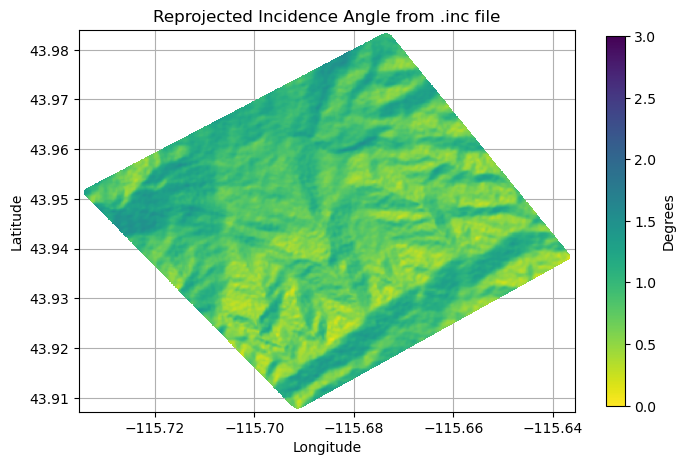

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
da_plot = da_reproj.plot(ax=ax, cmap='viridis_r', vmin=0, vmax=3, add_colorbar=False)
ax.set_title('Reprojected Incidence Angle from .inc file')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.colorbar(da_plot, ax=ax, orientation='vertical', label='Degrees', shrink=0.8)
plt.show()

In [ ]:
out_dir = '../data/snowex_lowman/slcs_geocoded/'
out_fp = "lowman_05208_inc_fromjpl.tif"
height, width = da_reproj.shape
transform = reprojected_dem.rio.transform()
crs = reprojected_dem.rio.crs

with rasterio.open(
    out_dir + out_fp,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype='float32',
    crs=crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(da_reproj.astype('float32'), 1)